## Requirement

1-Download the csv from https://www.kaggle.com/datasets/neha1703/movie-genre-from-its-poster$0

2- Put the csv in the local folder and name it "kaggle-movie.csv"

3- Put "movies.csv" in your local folder

In [1]:
import requests
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# Read-CSV & Clean
# ==========================================

df = pd.read_csv('movies.csv', engine='python')
df_kaggle = pd.read_csv('kaggle-movies.csv', engine='python', encoding='latin1')

os.makedirs('./posters', exist_ok=True)

# Drop rows where 'Poster_Url' is missing (NaN) for original dataset
df.dropna(subset=['Poster_Url'], inplace=True)
# Drop rows where 'Poster' is missing (NaN) for kaggle dataset
df_kaggle.dropna(subset=['Poster'], inplace=True)

# Save the cleaned datasets back to new CSVs
df.to_csv('movies_cleaned.csv', index=False)
df_kaggle.to_csv('kaggle-movies_cleaned.csv', index=False)

In [3]:
# df_kaggle titles often have years like 'Toy Story (1995)'. We strip them for a fairer comparison.
df_kaggle['Clean_Title'] = df_kaggle['Title'].astype(str).apply(lambda x: re.sub(r'\s*\(\d{4}\)', '', x).strip())
df['Clean_Title'] = df['Title'].astype(str).str.strip()

# Find intersection based on lowercased titles
df_titles = set(df['Clean_Title'].str.lower())
kaggle_titles = set(df_kaggle['Clean_Title'].str.lower())

common_movies = df_titles.intersection(kaggle_titles)
print(f"Number of unique movies in df: {len(df_titles)}")
print(f"Number of unique movies in df_kaggle: {len(kaggle_titles)}")
print(f"Number of movies present in BOTH datasets: {len(common_movies)}")
print(len(common_movies)/len(df_titles))

Number of unique movies in df: 9510
Number of unique movies in df_kaggle: 36766
Number of movies present in BOTH datasets: 5502
0.5785488958990537


In [4]:
# 2. Calculate the density of movie genres for df and df_kaggle

def get_genre_density(series):
    # Replace potential delimiters '|' with ',' and split into a list of genres
    exploded = series.dropna().astype(str).str.replace('|', ',', regex=False).str.split(',').explode().str.strip()
    # Remove empty strings if any
    exploded = exploded[exploded != '']
    return exploded.value_counts(normalize=True)

density_df = get_genre_density(df['Genre'])
density_kaggle = get_genre_density(df_kaggle['Genre'])
print(f"Number of unique genres in df: {len(density_df)}")
print(f"Number of unique genres in df_kaggle: {len(density_kaggle)}")

print("--- Top 3 Genres Density in df ---")
for genre, density in density_df.head(3).items():
    print(f"{genre}: {density:.4f} ({density * 100:.2f}%)")

print("\n--- Top 3 Genres Density in df_kaggle ---")
for genre, density in density_kaggle.head(3).items():
    print(f"{genre}: {density:.4f} ({density * 100:.2f}%)")

Number of unique genres in df: 19
Number of unique genres in df_kaggle: 28
--- Top 3 Genres Density in df ---
Drama: 0.1452 (14.52%)
Comedy: 0.1175 (11.75%)
Action: 0.1041 (10.41%)

--- Top 3 Genres Density in df_kaggle ---
Drama: 0.2333 (23.33%)
Comedy: 0.1476 (14.76%)
Romance: 0.0727 (7.27%)


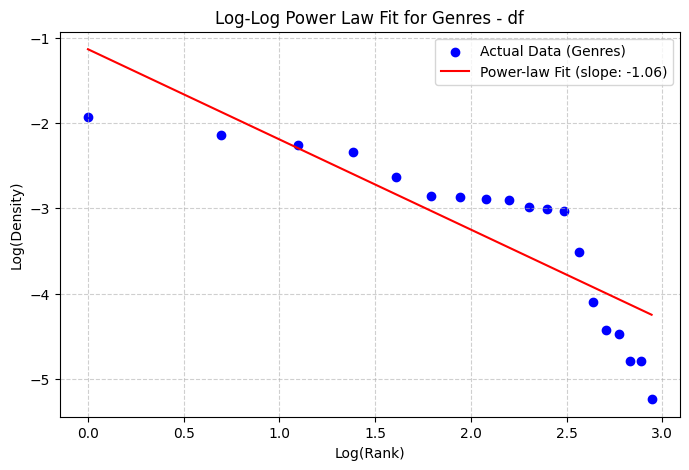

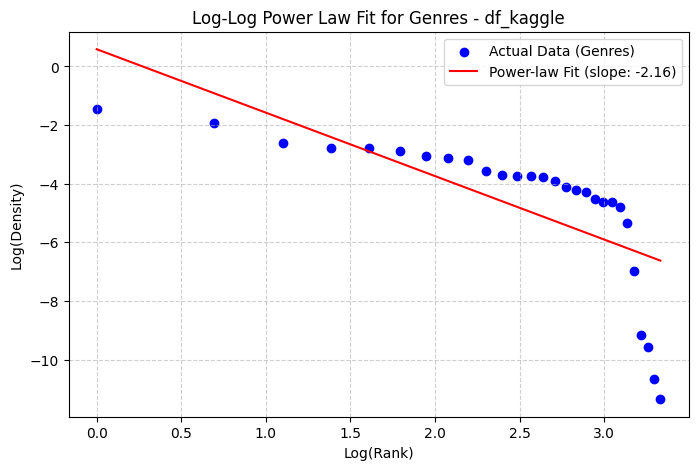

In [5]:
# 3. Use a log-log fit to fit a power law estimation on the genre distributions

def plot_power_law(density_series, dataset_name):
    # Ranks (1 to N) and Frequencies/Densities
    frequencies = density_series.values
    ranks = np.arange(1, len(frequencies) + 1)

    # Log transformations
    log_ranks = np.log(ranks)
    log_freqs = np.log(frequencies)

    # Fit a degree-1 polynomial (linear fit in log-log space)
    slope, intercept = np.polyfit(log_ranks, log_freqs, 1)
    fit_line = slope * log_ranks + intercept

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.scatter(log_ranks, log_freqs, color='blue', label='Actual Data (Genres)')
    plt.plot(log_ranks, fit_line, color='red', label=f'Power-law Fit (slope: {slope:.2f})')

    plt.title(f'Log-Log Power Law Fit for Genres - {dataset_name}')
    plt.xlabel('Log(Rank)')
    plt.ylabel('Log(Density)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_power_law(density_df, 'df')
plot_power_law(density_kaggle, 'df_kaggle')